In [ ]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV


# Data Preprocessing

The following preprocessing steps are performed:

- Load the dataset
- Create a Date column using Year and Month
- Sort the dataset chronologically
- Verify dataset information and missing values

Chronological ordering is essential before creating time-series features.

In [ ]:
df = pd.read_csv(r"C:\Users\sumit\Downloads\tesla_deliveries_dataset_2015_2025.csv")
print(df.head())

   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640  
2          

In [ ]:
print(df.shape)
print(df.info())

(2640, 12)
<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 247.6 KB
None


In [ ]:
# cheking for missing vals 
print(df.isnull().sum())

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [ ]:
df["Date"] = pd.to_datetime(
    dict(year = df["Year"],
    month = df["Month"],
    day = 1)
)
df = df.sort_values("Date")


# Exploratory Data Analysis

EDA helps understand the dataset through visualization.

The following visualizations are created:

1. Estimated Deliveries over Time
2. Production Units over Time
3. Distribution of Estimated Deliveries
4. Production Units vs Estimated Deliveries
5. Boxplot of Numerical Features


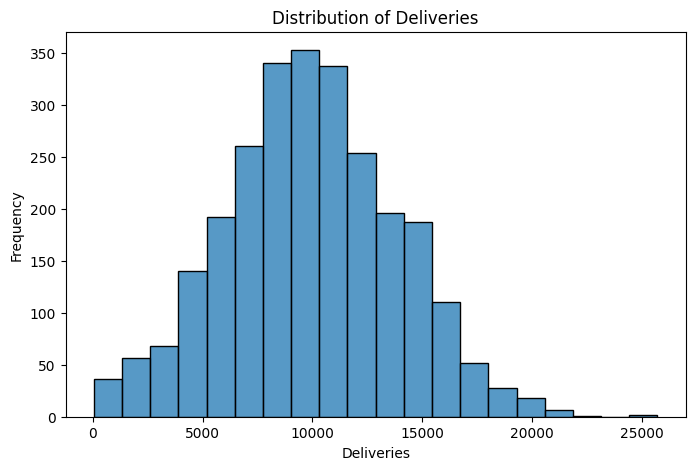

In [ ]:
#Charts
plt.figure(figsize = (8 , 5))
sns.histplot(df["Estimated_Deliveries"] , bins = 20)
plt.title("Distribution of Deliveries")
plt.xlabel("Deliveries")
plt.ylabel("Frequency")
plt.show()

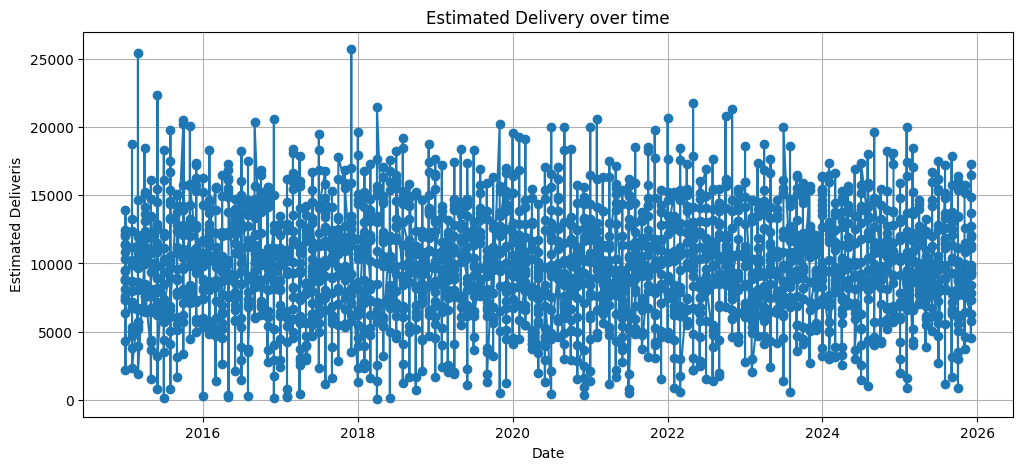

In [ ]:
plt.figure(figsize = (12 , 5))
plt.plot(df["Date"] , df["Estimated_Deliveries"] , marker = 'o')
plt.title("Estimated Delivery over time")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveris")
plt.grid(True)
plt.show()

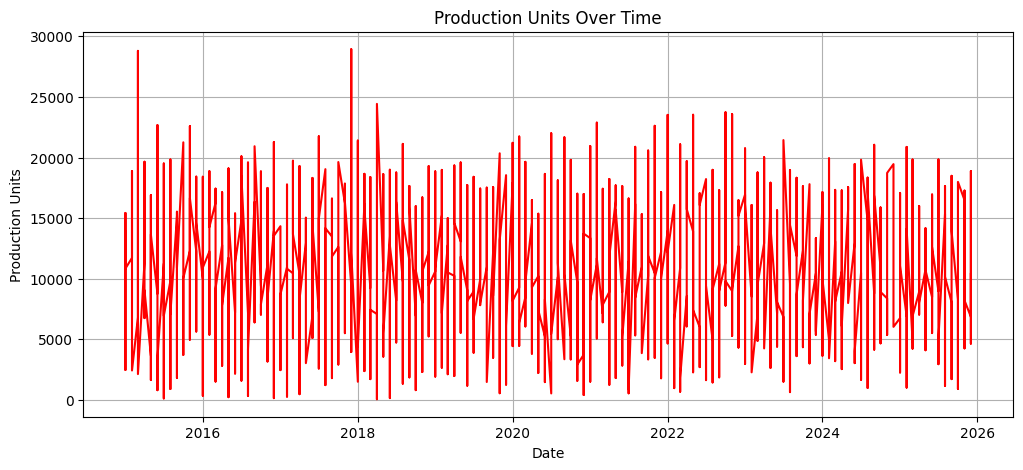

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Production_Units"], color='red')
plt.title("Production Units Over Time")
plt.xlabel("Date")
plt.ylabel("Production Units")
plt.grid(True)
plt.show()

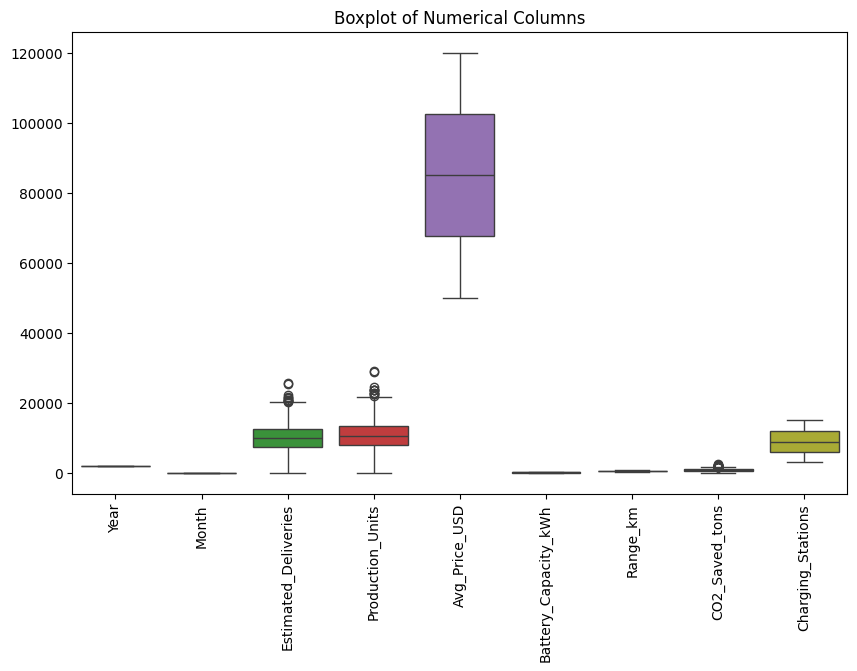

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.title("Boxplot of Numerical Columns")
plt.show()

# Correlation Analysis

A correlation heatmap is generated to measure relationships among numerical variables.

A strong positive correlation is observed between Production Units and Estimated Deliveries, indicating that production is one of the most influential predictors.

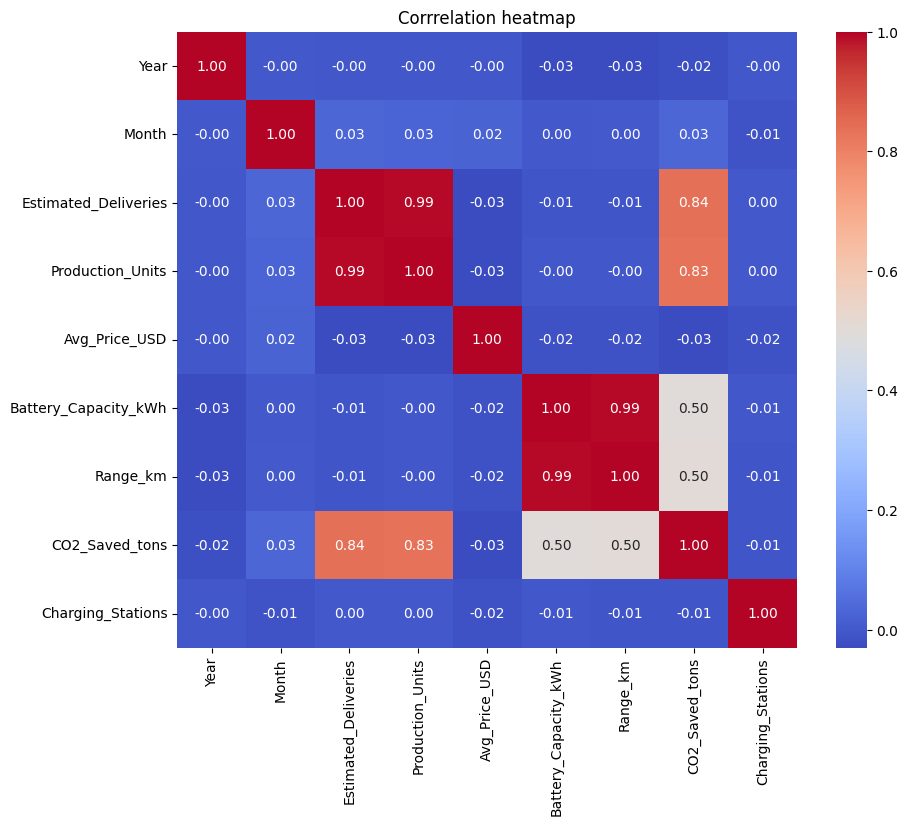

Estimated_Deliveries    1.000000
Production_Units        0.994234
CO2_Saved_tons          0.836814
Month                   0.030877
Charging_Stations       0.000753
Year                   -0.002863
Range_km               -0.006606
Battery_Capacity_kWh   -0.007765
Avg_Price_USD          -0.027546
Name: Estimated_Deliveries, dtype: float64


In [ ]:
plt.figure(figsize = (10,8))
corr = df.select_dtypes(include = np.number).corr()
sns.heatmap(
corr,
annot = True,
cmap = "coolwarm",
fmt = ".2f"
)
plt.title("Corrrelation heatmap")
plt.show()
print(corr["Estimated_Deliveries"].sort_values(ascending=False))

# Feature Engineering

To improve model performance, additional time-series features are created:

- Deliveries_Lag1
- Deliveries_Lag2
- RollingMean3

These features capture historical delivery patterns and trends.

Rows containing missing values after feature creation are removed.

In [ ]:
df["Deliveries_Lag1"] = df["Estimated_Deliveries"].shift(1)

df["Deliveries_Lag2"] = df["Estimated_Deliveries"].shift(2)

df["RollingMean3"] = (
    df["Estimated_Deliveries"]
      .shift(1)
      .rolling(window=3)
      .mean()
)

df.dropna(inplace=True)
print(df.isnull().sum())

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
Date                    0
Deliveries_Lag1         0
Deliveries_Lag2         0
RollingMean3            0
dtype: int64


# Augmented Dickey-Fuller (ADF) Test

The ADF test is performed to determine whether the delivery time series is stationary.

Decision Rule:

- p-value < 0.05 → Stationary
- p-value ≥ 0.05 → Non-Stationary

The obtained p-value indicates that the series is stationary.


In [ ]:
#ADF test
adf = adfuller(df["Estimated_Deliveries"])
print("ADF Statistic :", adf[0])
print("P-value :", adf[1])

if adf[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is Non-Stationary")

ADF Statistic : -28.207350011305046
P-value : 0.0
Series is Stationary


# Encoding Categorical Variables

Machine learning models require numerical input.

The categorical columns:

- Region
- Model
- Source_Type

are converted into numerical format using One-Hot Encoding.

In [ ]:
df = pd.get_dummies(
    df,
    columns=[
        "Region",
        "Model",
        "Source_Type"
    ],
    drop_first=True
)

In [ ]:
print(df.head(6))

      Year  Month  Estimated_Deliveries  Production_Units  Avg_Price_USD  \
2293  2015      1                  6367              6802      104962.32   
2215  2015      1                  8795              9165       87988.73   
2065  2015      1                  2161              2465      112637.91   
2023  2015      1                 11986             13302       91906.09   
1872  2015      1                  8833              8878      113652.43   
2469  2015      1                  9446              9528      110632.33   

      Battery_Capacity_kWh  Range_km  CO2_Saved_tons  Charging_Stations  \
2293                    82       459          438.37               9170   
2215                    82       456          601.58              12626   
2065                   120       695          225.28              14062   
2023                    82       457          821.64               4871   
1872                    82       461          610.80              10950   
2469             

In [ ]:
X = df.drop(
    columns=[
        "Estimated_Deliveries",
        "Date"
    ]
)
y= df["Estimated_Deliveries"]

In [ ]:
print(X.columns)

Index(['Year', 'Month', 'Production_Units', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations', 'Deliveries_Lag1', 'Deliveries_Lag2',
       'RollingMean3', 'Region_Europe', 'Region_Middle East',
       'Region_North America', 'Model_Model 3', 'Model_Model S',
       'Model_Model X', 'Model_Model Y', 'Source_Type_Interpolated (Month)',
       'Source_Type_Official (Quarter)'],
      dtype='str')


# Chronological Train-Test Split

The dataset is divided into:

- Training Set (80%)
- Testing Set (20%)

The split is performed chronologically to preserve the temporal order of observations and prevent information leakage.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

# Linear Regression

A Linear Regression model is trained using the training dataset.

Performance is evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

Cross-validation is also performed to measure model stability.

In [ ]:
#Applying Linear Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train , y_train)

#Prediction for linear regression
pred_lr = lr.predict(X_test)

#Measuring MAE ,RMSE, r2_R
mae_lr = mean_absolute_error(y_test , pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr = r2_score(y_test, pred_lr)

print("MAE :", mae_lr)
print("RMSE :", rmse_lr)
print("R2 :", r2_lr)


MAE : 320.66325510024865
RMSE : 390.3249410507824
R2 : 0.9885409965914904


In [ ]:
tscv = TimeSeriesSplit(n_splits=5)
scores = cross_val_score(
    lr,
    X,
    y,
    cv=tscv,
    scoring="r2"
)

print("\nCross Validation")

print("Mean R2 :", scores.mean())

print("Std Dev :", scores.std())



Cross Validation
Mean R2 : 0.9902218866838313
Std Dev : 0.0007893124138814423


# Hyperparameter Tuning using GridSearchCV

GridSearchCV is applied to optimize the Random Forest model.

Different combinations of parameters are evaluated to identify the best-performing model based on cross-validation.

In [ ]:
#Grid Search
param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2", None]
}
rf = RandomForestRegressor()
grid = GridSearchCV(

    estimator=rf,

    param_grid=params,

    cv=tscv,

    scoring="r2",

    n_jobs=-1

)

grid.fit(X_train, y_train)

print("Best Parameters")

print(grid.best_params_)



Best Parameters
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


# Random Forest Regression

The optimized Random Forest model is trained using the best hyperparameters obtained from GridSearchCV.

Model performance is evaluated using:

- MAE
- RMSE
- R² Score

In [ ]:
#taking best parameter from grid search
best_rf = grid.best_estimator_

pred_rf = best_rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)

rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))

r2_rf = r2_score(y_test, pred_rf)

print("\nRandom Forest")

print("MAE :", mae_rf)

print("RMSE :", rmse_rf)

print("R2 :", r2_rf)


Random Forest
MAE : 323.3023989826461
RMSE : 400.62785926916337
R2 : 0.9879280747982458


# Feature Importance

Feature importance is extracted from the Random Forest model.

The importance plot identifies the variables contributing most to delivery prediction.

Production Units and historical delivery features are expected to have the highest importance.

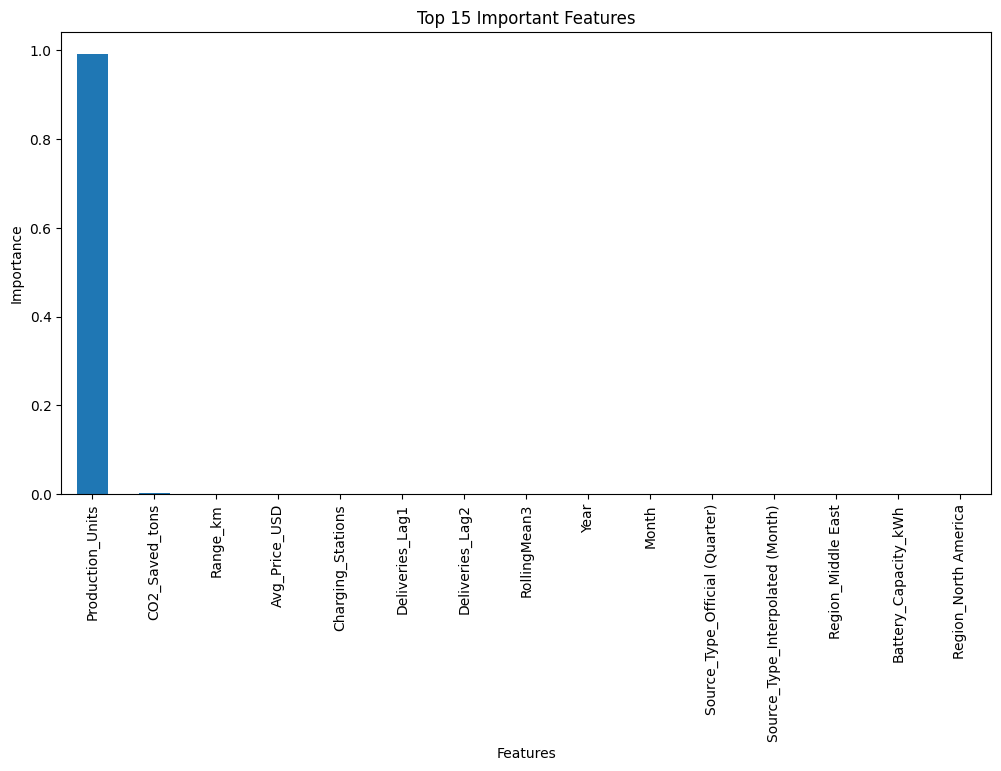

In [ ]:
importance = pd.Series(
    best_rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(
    ascending=False
)

plt.figure(figsize=(12,6))

importance.head(15).plot(kind="bar")

plt.title("Top 15 Important Features")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.show()

# Model Comparison

The performance of Linear Regression and Random Forest is compared using:

- Mean Absolute Error
- Root Mean Squared Error
- R² Score

The comparison helps determine which algorithm performs better on the given dataset.

In [ ]:
comparison = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Random Forest"
    ],

    "MAE":[
        mae_lr,
        mae_rf
    ],

    "RMSE":[
        rmse_lr,
        rmse_rf
    ],

    "R2":[
        r2_lr,
        r2_rf
    ]

})

print(comparison)

               Model         MAE        RMSE        R2
0  Linear Regression  320.663255  390.324941  0.988541
1      Random Forest  323.302399  400.627859  0.987928
